In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt

import os
import sys

sys.path.insert(0, r"C:\ProjectsDannyDavis\VolatilityPredictionProject\Utils")

import API_Keys
from File_Paths import raw_data_filepath
import OpenBBConvenienceFunctions as obb_cf
import PlottingFunctions as plot_func
from file_reader import read_file

from statsmodels import tsa
from statsmodels.graphics import tsaplots

In [2]:
SAP = read_file(raw_data_filepath, r"SP500_price_data.parquet")

In [3]:
SAP

,open,high,low,close,volume,simple_return,log_return
date,,,,,,,
2010-01-05,1132.660034,1136.630005,1129.660034,1136.520020,2491020000,0.003116,0.003111
2010-01-06,1135.709961,1139.189941,1133.949951,1137.140015,4972660000,0.000546,0.000545
2010-01-07,1136.270020,1142.459961,1131.319946,1141.689941,5270680000,0.004001,0.003993
2010-01-08,1140.520020,1145.390015,1136.219971,1144.979980,4389590000,0.002882,0.002878
2010-01-11,1145.959961,1149.739990,1142.020020,1146.979980,4255780000,0.001747,0.001745
...,...,...,...,...,...,...,...
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0.003221,0.003216
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,-0.000304,-0.000304
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,-0.003492,-0.003498


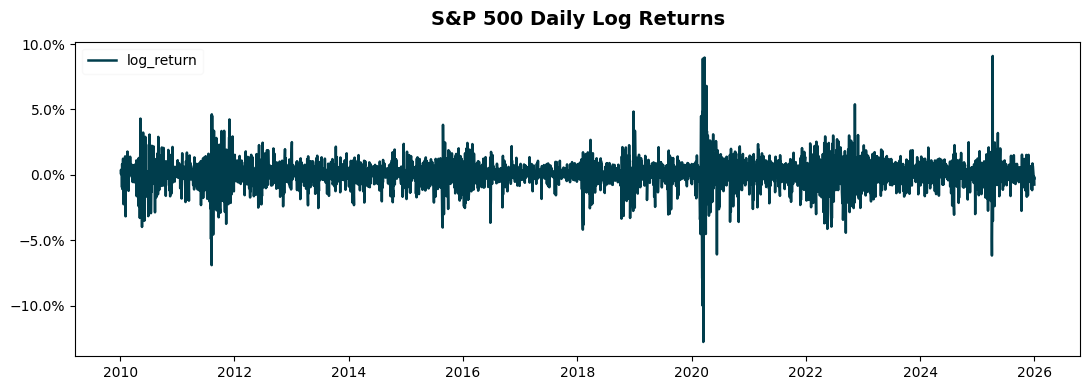

In [4]:
# Volatility clusters

plot_func.plot_line(data=SAP, y='log_return', title='S&P 500 Daily Log Returns', percent_y=True);

### VARIANCE

In [3]:
# Variance computation -- square of returns (assumes average daily return of 0)

SAP['var_simple'] = SAP['simple_return'] ** 2

SAP['var_log'] = SAP['log_return'] **2

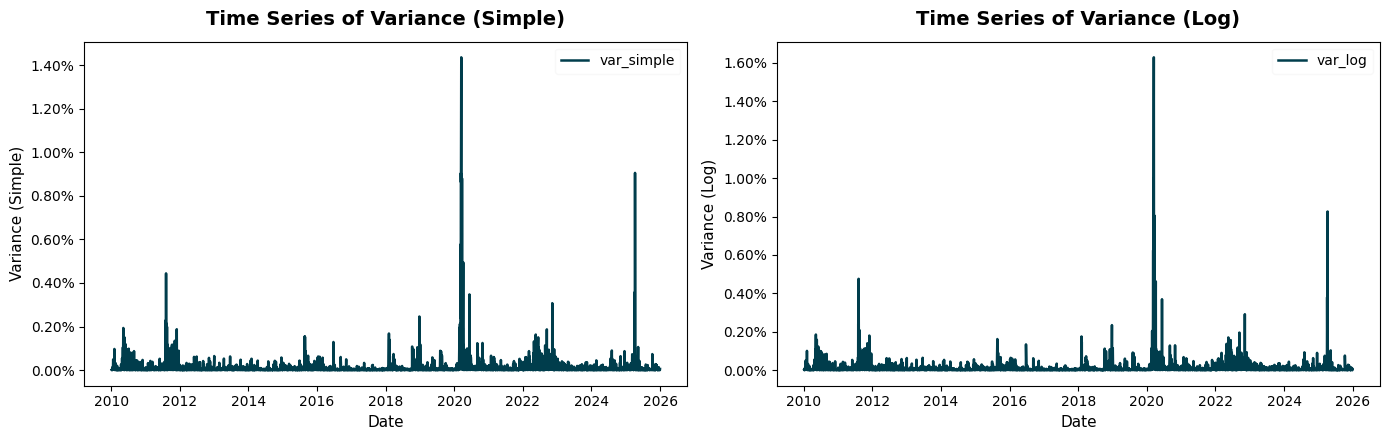

In [6]:
# Time series plot of variance

# var_simple plot configs
var_simple_config = {"type": "line", "data": SAP, "y":"var_simple", "title": "Time Series of Variance (Simple)","xlabel": "Date", "ylabel": "Variance (Simple)", "percent_y":True,}

# var_log plot configs
var_log_config = {"type": "line", "data": SAP, "y":"var_log", "title": "Time Series of Variance (Log)","xlabel": "Date", "ylabel": "Variance (Log)", "percent_y":True,}

plot_func.plot_subplots(plot_configs=[var_simple_config, var_log_config]);

### ACF

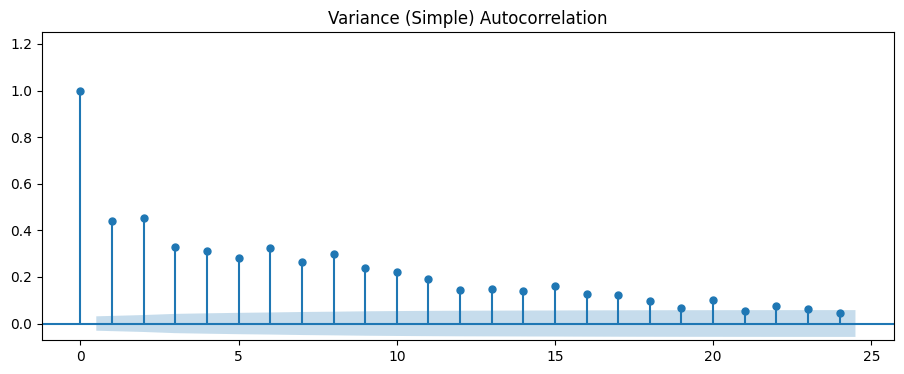

In [4]:
# Autocorrelation Function - var_simple

fig, ax = plot_func.create_ax(figsize=(11, 4))
tsaplots.plot_acf(x=SAP['var_simple'], lags=range(25), ax=ax,
                  title='Variance (Simple) Autocorrelation', auto_ylims=True, zero=False);

In [31]:
acf_simple, confint, qstat, pvalues = tsa.stattools.acf(
    x=SAP['var_simple'], nlags=25, alpha=0.05, qstat=True
)

acf_simple_df = pd.DataFrame(data={'acf':acf_simple[1:], 'qstat':qstat, 'pvalue':pvalues, 'lag':list(range(1, len(qstat)+1))}
                             ).set_index('lag')

# Ljung-Box Q-stat tests the null that all lags up to m are jointly zero

    # Below results show there is significance in a non-zero autocorrelation

acf_simple_df

,acf,qstat,pvalue
lag,,,
1,0.438891,775.510495,1.139262e-170
2,0.452333,1599.456841,0.000000e+00
3,0.327008,2030.188774,0.000000e+00
4,0.309300,2415.629162,0.000000e+00
5,0.279049,2729.439142,0.000000e+00
6,0.324120,3152.911579,0.000000e+00
7,0.261994,3429.672436,0.000000e+00
8,0.297696,3787.090931,0.000000e+00
9,0.237883,4015.369913,0.000000e+00
